# Surface terrestre visible en fonction de l'altitude

https://chatgpt.com/c/6a914b17-2c50-83eb-8728-d81a03318700

On utilise une Terre sphérique de rayon moyen **R = 6371 km**.

En posant `x = h/R`, le pourcentage de surface visible est :

$$P(x)=50\frac{x}{1+x}$$

Le notebook compare trois représentations :
- axes linéaires ;
- axe X logarithmique (semi-log) ;
- axes X et Y logarithmiques (log-log).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Rayon moyen de la Terre (km)
R = 6371.0

# Altitude relative x = h/R
x = np.logspace(-3, 4, 1000)

# Pourcentage de surface terrestre visible
P = 50 * x / (1 + x)

# Altitude géostationnaire
h_geo = 35786.0
x_geo = h_geo / R
P_geo = 50 * x_geo / (1 + x_geo)

print(f"R = {R:.0f} km")
print(f"Géostationnaire : h/R = {x_geo:.3f}")
print(f"Surface visible : {P_geo:.2f} %")

R = 6371 km
Géostationnaire : h/R = 5.617
Surface visible : 42.44 %


In [8]:
R = 6371.0  # rayon terrestre en km

def altitude_pourcentage(pourcentage):
    """
    Altitude nécessaire pour voir 'pourcentage' % de la surface terrestre.
    """

    P = pourcentage / 100

    if P <= 0 or P >= 0.5:
        raise ValueError("Le pourcentage doit être compris entre 0 et 50 %.")

    h = (2 * P * R) / (1 - 2 * P)

    return h


pourcentages = [1, 5, 10, 16.65, 20, 25, 30, 40, 45, 49]

print("Pourcentage   Altitude")
print("----------------------")

for p in pourcentages:
    h = altitude_pourcentage(p)
    print(f"{p:8.2f} %   {h:10.1f} km")

Pourcentage   Altitude
----------------------
    1.00 %        130.0 km
    5.00 %        707.9 km
   10.00 %       1592.8 km
   16.65 %       3180.7 km
   20.00 %       4247.3 km
   25.00 %       6371.0 km
   30.00 %       9556.5 km
   40.00 %      25484.0 km
   45.00 %      57339.0 km
   49.00 %     312179.0 km


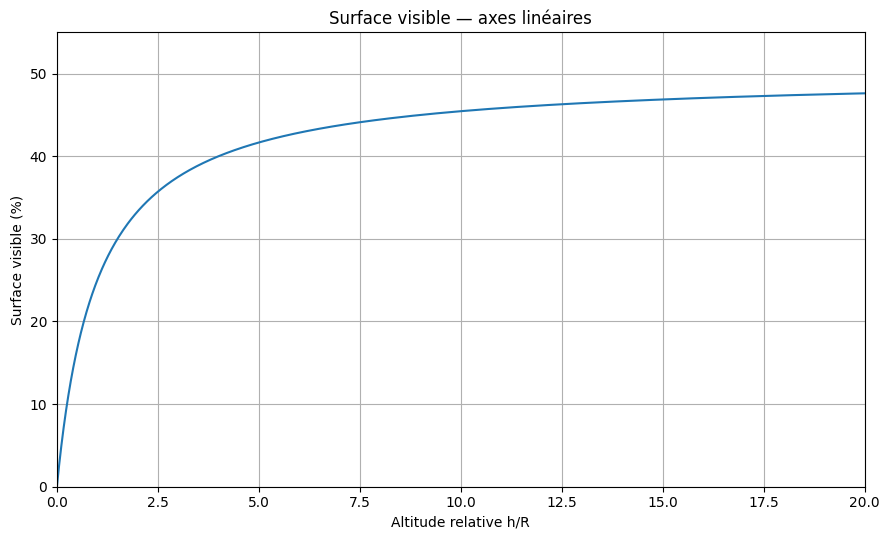

In [7]:
# 1. Axes linéaires
plt.figure(figsize=(9, 5.5))
plt.plot(x, P)
plt.xlabel("Altitude relative h/R")
plt.ylabel("Surface visible (%)")
plt.title("Surface visible — axes linéaires")
plt.xlim(0, 20)
plt.ylim(0, 55)
plt.grid(True)
plt.tight_layout()
plt.show()

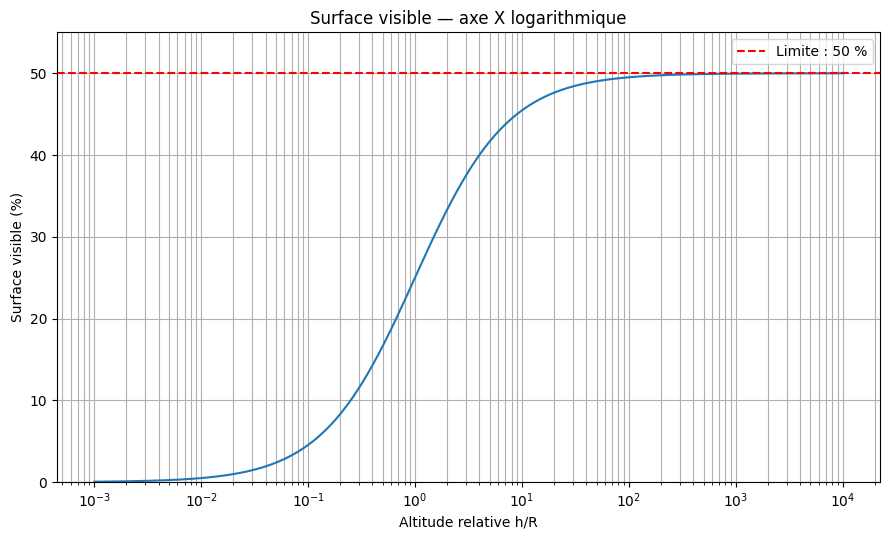

In [6]:
# 2. Semi-log : X logarithmique
plt.figure(figsize=(9, 5.5))
plt.plot(x, P)
plt.xscale("log")
plt.xlabel("Altitude relative h/R")
plt.ylabel("Surface visible (%)")
plt.title("Surface visible — axe X logarithmique")
plt.ylim(0, 55)
plt.axhline(50, linestyle="--", color='red', label="Limite : 50 %")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

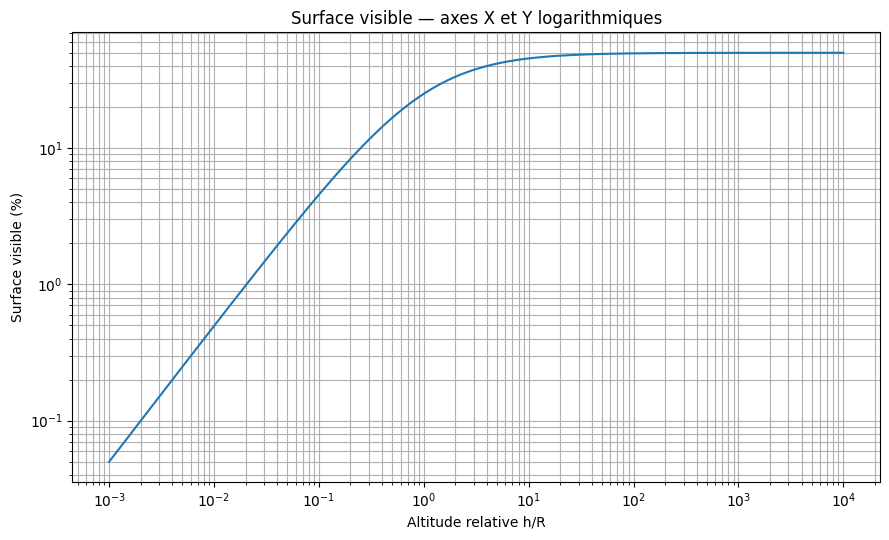

In [4]:
# 3. Log-log : X et Y logarithmiques
plt.figure(figsize=(9, 5.5))
plt.plot(x, P)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Altitude relative h/R")
plt.ylabel("Surface visible (%)")
plt.title("Surface visible — axes X et Y logarithmiques")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

## Quelques valeurs remarquables

La relation est :

$$P=50\frac{h/R}{1+h/R}$$

Ainsi :
- `h/R = 0` → 0 %
- `h/R = 1` → 25 %
- `h/R = 5.62` → environ 42,4 % (orbite géostationnaire)
- `h/R → ∞` → 50 %